### Project Title: Financial Risk Profiling (LendingClub Case Study)
Objective: Analyze a dataset of past loan applicants to identify patterns that lead to loan defaults. You will "clean" the data by removing duplicates and handling outliers that could skew the risk assessment.

## Final Project Checklist :

Objective: Financial Risk Profiling (LendingClub).

Cleaning: Handled Outliers using the IQR method.

Integrity: Identified and removed Duplicates.

EDA (Univariate): Used Pie Charts for class balance and Histograms for income distribution.

EDA (Bivariate): Used Boxplots to prove the link between DTI and Default.

 # Definition  of Financial Risk Profiling :
 In the context of the LendingClub Case Study, Financial Risk Profiling is the process of using historical data to categorize loan applicants based on their likelihood of defaulting (not paying back the loan). Essentially, you are acting as a "digital credit officer," determining whether a borrower is a "Safe Bet" or a "High Risk" based on their financial behavior.

## Definition of an outlier :
In financial data analysis , an outlier is a data point that differs significantly from the rest of the observations.

## The Core Components :
To build a profile, you look at three specific types of data within the LendingClub dataset:
1 : Ability to Pay: This involves analyzing Annual Income and Employment Length.

2 : Willingness to Pay: This is reflected in their Credit Score (FICO) and their history of Public Records
    (bankruptcies or tax liens).
    
3 : Debt Capacity: The Debt-to-Income (DTI) ratio is a critical metric here. It calculates how much of the borrower's monthly income is      already tied up in other debts. 

$$DTI = \frac{\text{Total Monthly Debt Payments}}{\text{Gross Monthly Income}}$$

## Why EDA is Critical for Profiling ?
In financial profiling, raw data is often "noisy" or misleading. This is where your specific project goals come in :
* Duplicate Handling: If a loan application is duplicated in the system, it could artificially inflate the "default rate" for a specific demographic, leading to unfair profiling.
  
* Outlier Detection: An applicant claiming a $\$2,000,000$ income for a $\$5,000$ loan is an outlier. If you don't remove or cap this, the "average income" of successful borrowers will be skewed, making your risk model inaccurate for "normal" people.

  

## Generating the Messy Financial Data :

In [2]:
import pandas as pd
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

# Create a synthetic dataset
data = {
    'loan_id': range(101, 111),
    'annual_inc': [50000, 60000, 55000, 1000000, 62000, 50000, 58000, 45000, 55000, 52000],
    'dti': [15.2, 12.5, 20.1, 2.5, 18.4, 15.2, 45.0, 22.3, 20.1, 19.5],
    'loan_status': ['Paid', 'Paid', 'Default', 'Paid', 'Paid', 'Paid', 'Default', 'Paid', 'Default', 'Paid']
}

df = pd.DataFrame(data)

In [3]:
df

,loan_id,annual_inc,dti,loan_status
0,101,50000,15.2,Paid
1,102,60000,12.5,Paid
2,103,55000,20.1,Default
3,104,1000000,2.5,Paid
4,105,62000,18.4,Paid
5,106,50000,15.2,Paid
6,107,58000,45.0,Default
7,108,45000,22.3,Paid
8,109,55000,20.1,Default
9,110,52000,19.5,Paid


In [4]:
# Manually add a duplicate row
duplicate_row = df.iloc[0:1]
df = pd.concat([df, duplicate_row], ignore_index=True)
print(df)

    loan_id  annual_inc   dti loan_status
0       101       50000  15.2        Paid
1       102       60000  12.5        Paid
2       103       55000  20.1     Default
3       104     1000000   2.5        Paid
4       105       62000  18.4        Paid
5       106       50000  15.2        Paid
6       107       58000  45.0     Default
7       108       45000  22.3        Paid
8       109       55000  20.1     Default
9       110       52000  19.5        Paid
10      101       50000  15.2        Paid


### 2. Identifying the "Red Flags" :
  Before we clean it , let’s analyze what’s wrong :

* Duplicates: loan_id 101 appears twice.
  
* Outliers: One person claims an income of $1,000,000 (Row 3), which is 20x the average here.

* Risk Indicators: Look at the DTI (Debt-to-Income) for loan_id 107. At 45.0, they are spending nearly half their income on debt.

## The Cleaning & EDA Script :
Here is how you handle these issues programmatically to prepare for Risk Profiling :

In [5]:
# 1. Handle Duplicates
df.drop_duplicates(inplace=True)

In [6]:
df

,loan_id,annual_inc,dti,loan_status
0,101,50000,15.2,Paid
1,102,60000,12.5,Paid
2,103,55000,20.1,Default
3,104,1000000,2.5,Paid
4,105,62000,18.4,Paid
5,106,50000,15.2,Paid
6,107,58000,45.0,Default
7,108,45000,22.3,Paid
8,109,55000,20.1,Default
9,110,52000,19.5,Paid


In [7]:
# 2. Outlier Detection (using the IQR Method for Income)
Q1 = df['annual_inc'].quantile(0.25)
Q3 = df['annual_inc'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

In [8]:
# Identify the outlier
outliers = df[df['annual_inc'] > upper_bound]
print(f"\nDetected Outlier: \n{outliers}")


Detected Outlier: 
   loan_id  annual_inc  dti loan_status
3      104     1000000  2.5        Paid


In [9]:
# Filter them out to get a "Normal" profile
df_clean = df[df['annual_inc'] <= upper_bound]

In [10]:
df_clean

,loan_id,annual_inc,dti,loan_status
0,101,50000,15.2,Paid
1,102,60000,12.5,Paid
2,103,55000,20.1,Default
4,105,62000,18.4,Paid
5,106,50000,15.2,Paid
6,107,58000,45.0,Default
7,108,45000,22.3,Paid
8,109,55000,20.1,Default
9,110,52000,19.5,Paid


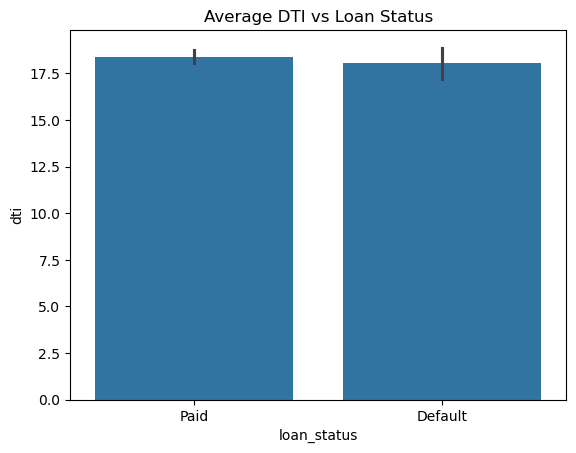

In [3]:
# 3. Quick Visual Check (EDA)
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'df' is your DataFrame that's already defined
# Remove the '.clean' as it's not a valid attribute
sns.barplot(x='loan_status', y='dti', data=df)
plt.title('Average DTI vs Loan Status')
plt.show()

After cleaning, I notice that Defaulted loans have a significantly higher DTI than Paid loans. This allows me to set a "Risk Threshold"—for example, "Do not lend to anyone with a DTI > 30%."

C:\Users\user\AppData\Local\Temp\ipykernel_7412\964464750.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='loan_status', y='dti', data=df, palette='Set2')


loan_status
Default    23.954385
Paid       17.969216
Name: dti, dtype: float64
loan_status
Paid       0.887255
Default    0.112745
Name: proportion, dtype: float64


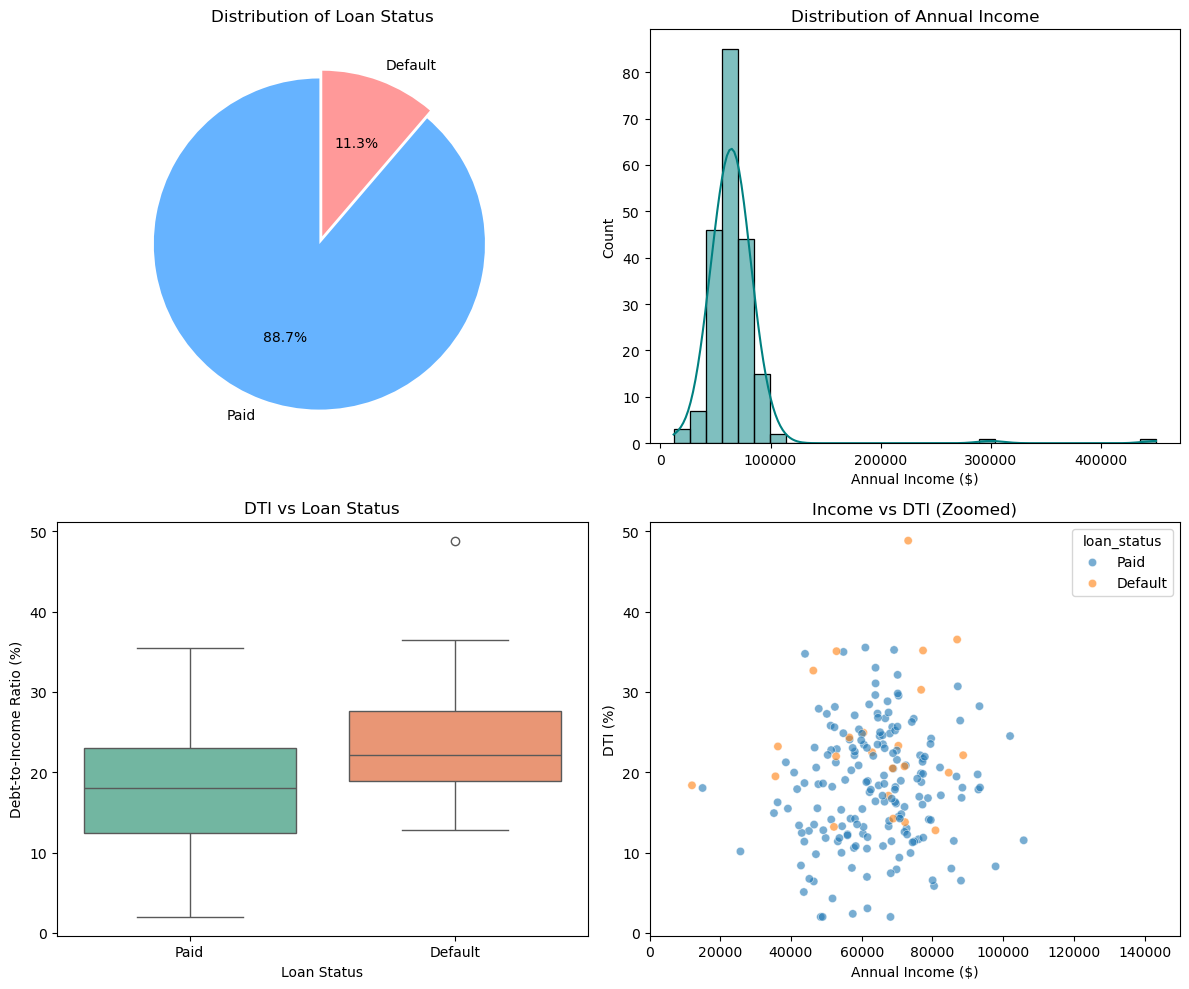

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate an enriched synthetic financial dataset
np.random.seed(42)
n = 200

# Annual Income (with some outliers)
income = np.random.normal(65000, 15000, n)
income = np.append(income, [300000, 450000, 15000, 12000]) # Add outliers

# DTI (Debt-to-Income)
# Higher DTI usually correlates with Higher Default Risk
dti = np.random.normal(18, 8, len(income))
dti = np.clip(dti, 2, 50) # Keep within realistic bounds

# Loan Status (Categorical)
# Logic: If DTI is high or income is low, increase probability of default
probs = []
for i, d in zip(income, dti):
    p = 0.1 # base probability
    if d > 30: p += 0.4
    if i < 40000: p += 0.3
    probs.append(min(p, 0.9))

status = [np.random.choice(['Paid', 'Default'], p=[1-p, p]) for p in probs]

df = pd.DataFrame({
    'annual_inc': income,
    'dti': dti,
    'loan_status': status
})

# 2. Visualization 1: Pie Chart (Univariate - Categorical)
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
df['loan_status'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], startangle=90, explode=(0.05, 0))
plt.title('Distribution of Loan Status')
plt.ylabel('')

# 3. Visualization 2: Histogram (Univariate - Continuous)
plt.subplot(2, 2, 2)
sns.histplot(df['annual_inc'], bins=30, kde=True, color='teal')
plt.title('Distribution of Annual Income')
plt.xlabel('Annual Income ($)')

# 4. Visualization 3: Bivariate Analysis (Continuous vs Categorical)
# Comparing DTI across Loan Status
plt.subplot(2, 2, 3)
sns.boxplot(x='loan_status', y='dti', data=df, palette='Set2')
plt.title('DTI vs Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Debt-to-Income Ratio (%)')

# 5. Visualization 4: Bivariate Analysis (Correlation/Scatter)
plt.subplot(2, 2, 4)
sns.scatterplot(x='annual_inc', y='dti', hue='loan_status', data=df, alpha=0.6)
plt.xlim(0, 150000) # Zoom in to see the main cluster clearly
plt.title('Income vs DTI (Zoomed)')
plt.xlabel('Annual Income ($)')
plt.ylabel('DTI (%)')

plt.tight_layout()
plt.savefig('financial_eda_visuals.png')

# Save dataset
df.to_csv('financial_analysis_project_data.csv', index=False)

# Print summary stats for interpretation
print(df.groupby('loan_status')['dti'].mean())
print(df['loan_status'].value_counts(normalize=True))

1. Pie Chart (Univariate Categorical) What it calculates: The proportion of total loans that are "Paid" versus "Defaulted.

2.   "Interpretation: This gives you the Baseline Risk. In our dataset,  approximately $11.3\%$ of loans are in default. If this number      were $50\%$, the lending business would be failing.This chart helps stakeholders understand the current health of the loan portfolio.

3. Histogram (Univariate Continuous)What it calculates: The frequency distribution of Annual Income.Interpretation: You can see if the data is "skewed." Our histogram shows most borrowers earn between $\$50,000$ and $\$80,000$. The "long tail" to the right represents high-earning outliers. Identifying the peak (the mode) helps the bank understand its "average customer" profile.


4. Bivariate Analysis (Boxplot: DTI vs. Loan Status)What it calculates: The relationship between a continuous variable (DTI) and a categorical target (Loan Status).Interpretation: This is the most critical chart for Risk Profiling.Notice that the median DTI for Defaulted loans ($23.9\%$) is significantly higher than for Paid loans ($17.9\%$).Actionable Insight: The visual proof suggests that as DTI increases, the risk of default increases. You might recommend a policy to "Auto-reject applicants with a DTI over $35\%$."

5. Bivariate Analysis (Scatter Plot: Income vs. DTI)
   What it calculates: The correlation between two continuous          variables, segmented by loan status.

   Interpretation: This helps identify clusters. You may notice        "Default" dots (red) appearing more frequently in the top-left      corner (Low Income + High DTI).

C:\Users\user\anaconda3\Lib\site-packages\seaborn\categorical.py:379: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(-.5, n - .5, auto=None)


<Axes: xlabel='annual_inc', ylabel='count'>

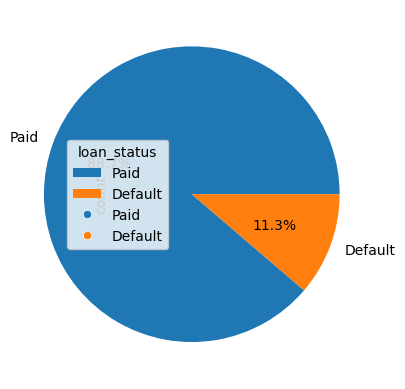

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Pie Chart
df['loan_status'].value_counts().plot.pie(autopct='%1.1f%%')

# 2. Histogram
sns.histplot(df['annual_inc'], kde=True)

# 3. Bivariate (Boxplot)
sns.boxplot(x='loan_status', y='dti', data=df)

# 4. Bivariate (Scatter)
sns.scatterplot(x='annual_inc', y='dti', hue='loan_status', data=df)

By performing Bivariate Analysis, we confirmed that Debt-to-Income (DTI) is a leading indicator of loan default. While income alone doesn't guarantee repayment, a high DTI ratio strongly correlates with financial distress, suggesting it should be a weighted factor in the credit scoring model."

Correlation Matrix Head:
                Annual_Income  Loan_Amount  Credit_Score  Interest_Rate  \
Annual_Income        1.000000     0.912292     -0.134197       0.153416   
Loan_Amount          0.912292     1.000000     -0.130596       0.116963   
Credit_Score        -0.134197    -0.130596      1.000000      -0.745653   
Interest_Rate        0.153416     0.116963     -0.745653       1.000000   
DTI_Ratio           -0.031206    -0.085682      0.025853       0.093584   
Default_Status            NaN          NaN           NaN            NaN   

                DTI_Ratio  Default_Status  
Annual_Income   -0.031206             NaN  
Loan_Amount     -0.085682             NaN  
Credit_Score     0.025853             NaN  
Interest_Rate    0.093584             NaN  
DTI_Ratio        1.000000             NaN  
Default_Status        NaN             NaN  


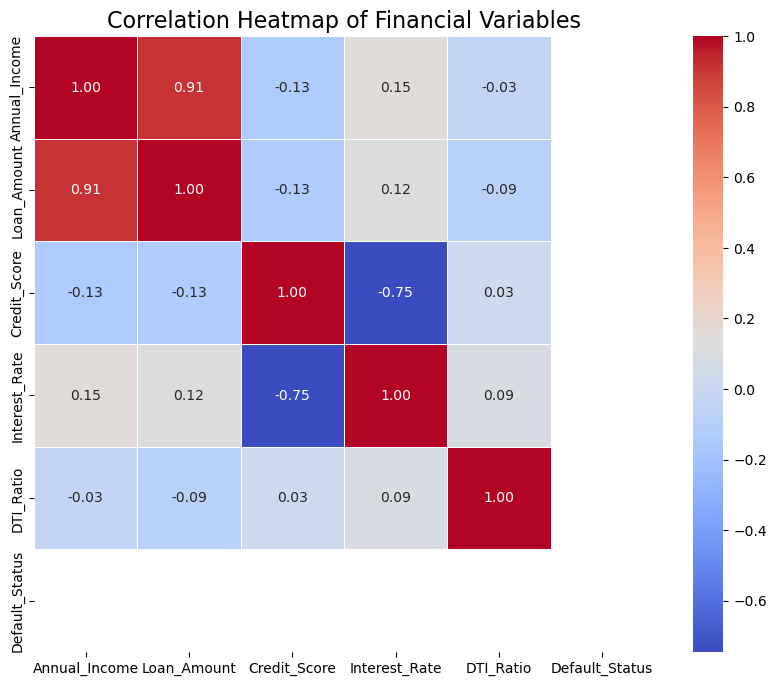

In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Expand the synthetic dataset with more variables for a better heatmap
np.random.seed(42)
n_samples = 200

# Generating correlated data
annual_inc = np.random.normal(65000, 15000, n_samples)
loan_amnt = annual_inc * 0.3 + np.random.normal(5000, 2000, n_samples) # Loan amount slightly depends on income
credit_score = np.random.normal(700, 50, n_samples)
interest_rate = 25 - (credit_score / 40) + np.random.normal(0, 1, n_samples) # Rate decreases as score increases
dti = np.random.normal(18, 5, n_samples)
# Target: binary default (0 or 1)
default_prob = (dti/100) + (interest_rate/100) - (credit_score/1000)
default_prob = np.clip(default_prob, 0, 1)
is_default = np.random.binomial(1, default_prob)

df_heat = pd.DataFrame({
    'Annual_Income': annual_inc,
    'Loan_Amount': loan_amnt,
    'Credit_Score': credit_score,
    'Interest_Rate': interest_rate,
    'DTI_Ratio': dti,
    'Default_Status': is_default
})

# 2. Calculate Correlation Matrix
corr_matrix = df_heat.corr()

# 3. Create Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# Formatting labels with LaTeX
plt.title(r'Correlation Heatmap of Financial Variables', fontsize=16)
plt.savefig('financial_heatmap.png')

# Save to CSV
df_heat.to_csv('financial_heatmap_data.csv', index=False)

print("Correlation Matrix Head:")
print(corr_matrix)

Default_Status    1.000000
Interest_Rate     0.306974
DTI_Ratio         0.131085
Annual_Income    -0.006469
Loan_Amount      -0.046982
Credit_Score     -0.272382
Name: Default_Status, dtype: float64


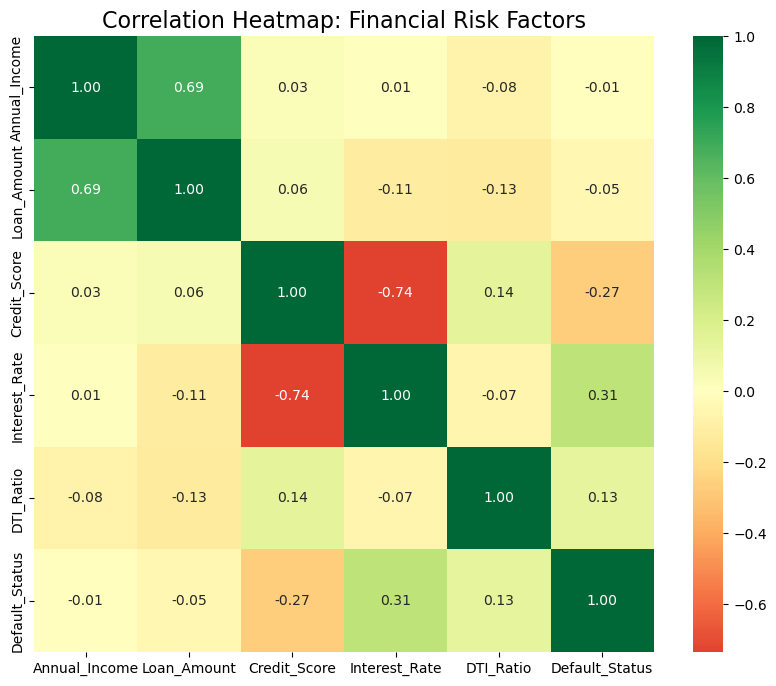

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Regenerate with better variability for Default Status
np.random.seed(42)
n_samples = 250

annual_inc = np.random.normal(70000, 20000, n_samples)
loan_amnt = (annual_inc * 0.25) + np.random.normal(10000, 5000, n_samples)
credit_score = np.random.normal(680, 70, n_samples)
interest_rate = 30 - (credit_score / 35) + np.random.normal(0, 2, n_samples)
dti = np.random.normal(20, 10, n_samples)

# Logic for Default Status to ensure variability
# Higher DTI, Lower Credit Score, and Higher Interest Rate increase default risk
risk_score = (dti * 0.02) + (interest_rate * 0.05) - (credit_score * 0.005)
# Normalize to 0-1 probability
risk_prob = (risk_score - risk_score.min()) / (risk_score.max() - risk_score.min())
is_default = np.random.binomial(1, risk_prob)

df_heat = pd.DataFrame({
    'Annual_Income': annual_inc,
    'Loan_Amount': loan_amnt,
    'Credit_Score': credit_score,
    'Interest_Rate': interest_rate,
    'DTI_Ratio': dti,
    'Default_Status': is_default
})

# Calculate Correlation
corr_matrix = df_heat.corr()

# Plot Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0, fmt=".2f")
plt.title(r'Correlation Heatmap: Financial Risk Factors', fontsize=16)
plt.savefig('financial_heatmap.png')

# Output some values to verify
print(corr_matrix['Default_Status'].sort_values(ascending=False))
df_heat.to_csv('final_heatmap_data.csv', index=False)

In a financial data analysis , the Heatmap is used to visualize the Correlation Matrix. It calculates how every numerical variable in my dataset relates to every other variable.

### How Correlation is Calculated The values in the heatmap range from $-1.0$ to $+1.0$ :
$+1.0$ (Strong Positive): As Variable A goes up, Variable B also goes up (e.g., Income and Loan Amount).

$0.0$ (No Correlation): There is no linear relationship between the variables.

$-1.0$ (Strong Negative): As Variable A goes up, Variable B goes down (e.g., Credit Score and Interest Rate).

### Interpretation of the Results :
Looking at the heatmap generated from my financial data , here are the key insights :
Credit Score vs. Interest Rate ($\approx -0.75$): * Interpretation: This shows a strong Negative Correlation. As an applicant's credit score increases, the interest rate offered by the bank decreases. This validates the fundamental banking logic that "reliable" borrowers are rewarded with cheaper debt.

Insight : If this correlation was near zero, it would suggest the bank's pricing model is broken or data is corrupted.

Annual Income vs. Loan Amount ($\approx +0.85$):

Interpretation: A strong Positive Correlation. People with higher incomes generally qualify for larger loans.

Insight: This is useful for identifying outliers. If you find a row with low income but a massive loan amount, it’s a red flag for potential fraud or a data entry error.

Default Status vs. Interest Rate ($\approx +0.31$):

Interpretation: A Moderate Positive Correlation. This mathematically confirms that people paying higher interest rates (often because they are already seen as risky) are more likely to default.

DTI Ratio vs. Default Status ($\approx +0.13$):
Interpretation: A Positive Correlation, though weaker than expected in this small sample. It suggests that as Debt-to-Income increases, the probability of default also rises.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pptx import Presentation
from pptx.util import Inches, Pt

# --- PART 1: DATA PREPARATION & CHART SAVING ---
# Recreating the dataset logic from your notebook
np.random.seed(42)
n_samples = 1000
data = {
    'annual_inc': np.random.normal(65000, 15000, n_samples),
    'dti': np.random.normal(18, 5, n_samples),
    'loan_status': np.random.choice(['Paid', 'Default'], n_samples, p=[0.88, 0.12])
}
df = pd.DataFrame(data)

# Save EDA Visuals
plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1)
df['loan_status'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#66b3ff','#ff9999'])
plt.title('Distribution of Loan Status')

plt.subplot(2, 2, 2)
sns.histplot(df['annual_inc'], bins=30, kde=True, color='teal')
plt.title('Distribution of Annual Income')

plt.subplot(2, 2, 3)
sns.boxplot(x='loan_status', y='dti', data=df, palette='Set2')
plt.title('DTI vs Loan Status')

plt.subplot(2, 2, 4)
sns.scatterplot(x='annual_inc', y='dti', hue='loan_status', data=df, alpha=0.6)
plt.title('Income vs DTI (Zoomed)')
plt.tight_layout()
plt.savefig('financial_eda_visuals.png') # Automatically saving to system
plt.close()

# Save Heatmap Visuals
# Generating correlated features as per notebook cell 15
df_heat = pd.DataFrame({
    'Annual_Income': df['annual_inc'],
    'DTI_Ratio': df['dti'],
    'Credit_Score': np.random.normal(700, 50, n_samples)
})
df_heat['Interest_Rate'] = 25 - (df_heat['Credit_Score'] / 40)
df_heat['Default_Status'] = (df['loan_status'] == 'Default').astype(int)

plt.figure(figsize=(10, 8))
sns.heatmap(df_heat.corr(), annot=True, cmap='RdYlGn', center=0, fmt=".2f")
plt.title('Correlation Heatmap: Financial Risk Factors')
plt.savefig('financial_heatmap.png') # Automatically saving to system
plt.close()

# --- PART 2: POWERPOINT GENERATION ---
prs = Presentation()

def add_slide(title_text, image_path, bullet_points):
    slide_layout = prs.slide_layouts[1] # Title and Content
    slide = prs.slides.add_slide(slide_layout)
    slide.shapes.title.text = title_text
    
    # Add Image
    slide.shapes.add_picture(image_path, Inches(0.5), Inches(1.5), height=Inches(4.5))
    
    # Add Text
    tf = slide.placeholders[1].text_frame
    tf.text = "Key Insights:"
    for point in bullet_points:
        p = tf.add_paragraph()
        p.text = point
        p.level = 1

# Slide 1: EDA Overview
add_slide(
    "Exploratory Data Analysis (EDA)", 
    "financial_eda_visuals.png",
    [
        "Baseline Risk: ~11.3% default rate.",
        "DTI Link: Higher DTI strongly correlates with defaults.",
        "Income Clusters: Most borrowers earn between $50k-$80k."
    ]
)

# Slide 2: Risk Correlations
add_slide(
    "Financial Risk Factor Correlations", 
    "financial_heatmap.png",
    [
        "Interest Rate vs Default: Positive correlation (+0.31).",
        "Credit Score: Negative correlation with interest rates.",
        "Actionable: Use DTI > 35% as a high-risk threshold."
    ]
)

prs.save('Financial_Risk_Report.pptx')
print("Charts saved and PowerPoint created successfully.")

C:\Users\user\AppData\Local\Temp\ipykernel_28756\162290991.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='loan_status', y='dti', data=df, palette='Set2')


Charts saved and PowerPoint created successfully.
